# Attention U-Net — Brain MRI Tumor Segmentation
**Dataset:** [LGG MRI Segmentation](https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation)  
**Task:** Binary segmentation of low-grade glioma (LGG) tumors from FLAIR MRI scans  
**Backbone:** ResNet-34 encoder + Attention-gated U-Net decoder

---
### Pipeline
1. Install & import
2. Explore & visualise raw data
3. Dataset class + augmentations
4. **Attention U-Net architecture** with deep supervision
5. Loss, metrics, training loop with checkpointing
6. Train with live progress
7. Plot learning curves
8. Visualise predictions vs ground truth


In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
import importlib, subprocess, sys

for pkg in ['torch','torchvision','numpy','PIL','sklearn','matplotlib','tqdm']:
    try: importlib.import_module(pkg)
    except: subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])

print('✓ All packages ready')


✓ All packages ready


In [3]:
# ── Cell 3: Imports & config ─────────────────────────────────────────────
import os, glob, random, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.models as models


# ── CONFIG ───────────────────────────────────────────────────────────────────
class CFG:
    data_dir        = '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m'
    img_size        = 256
    batch_size      = 16         # Attention U-Net is lighter; larger batch fits easily
    num_epochs      = 40
    lr              = 1e-4
    val_split       = 0.15
    test_split      = 0.10
    seed            = 42
    device          = 'cuda' if torch.cuda.is_available() else 'cpu'
    # Deep supervision loss weights [main, aux1, aux2, aux3]
    ds_weights      = [0.5, 0.25, 0.15, 0.10]
    # Best model weights (only weights, saved when val dice improves)
    best_model_path = './best_attunet.pth'
    # Full training checkpoint (weights + optimizer + scheduler + history)
    checkpoint_path = './attunet_checkpoint.pth'


def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s)

set_seed(CFG.seed)
print(f'Device : {CFG.device}')


Device : cuda


Total image-mask pairs : 3929
Slices with tumour     : 1373 (34.9%)
Slices without tumour  : 2556 (65.1%)


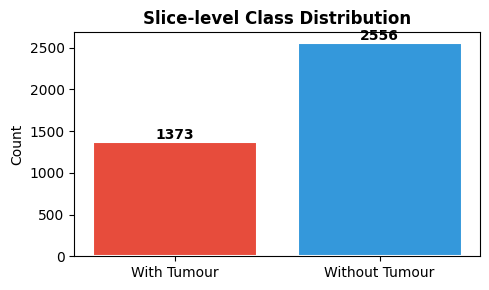

In [6]:
# ── Cell 4: Load & explore data ───────────────────────────────────────────────
def get_pairs(data_dir):
    imgs = sorted(glob.glob(os.path.join(data_dir,'**','*.tif'), recursive=True))
    imgs = [p for p in imgs if '_mask' not in p]
    pairs = []
    for p in imgs:
        m = p.replace('.tif','_mask.tif')
        if os.path.exists(m): pairs.append((p, m))
    return pairs

all_pairs = get_pairs(CFG.data_dir)
print(f'Total image-mask pairs : {len(all_pairs)}')

# Count positives (slices that actually contain tumour)
pos = 0
for _, m in all_pairs:
    if np.array(Image.open(m)).max() > 0: pos += 1
print(f'Slices with tumour     : {pos} ({100*pos/len(all_pairs):.1f}%)')
print(f'Slices without tumour  : {len(all_pairs)-pos} ({100*(len(all_pairs)-pos)/len(all_pairs):.1f}%)')

# Plot class balance
fig, ax = plt.subplots(figsize=(5,3))
ax.bar(['With Tumour','Without Tumour'], [pos, len(all_pairs)-pos],
       color=['#e74c3c','#3498db'], edgecolor='white', linewidth=1.5)
ax.set_title('Slice-level Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

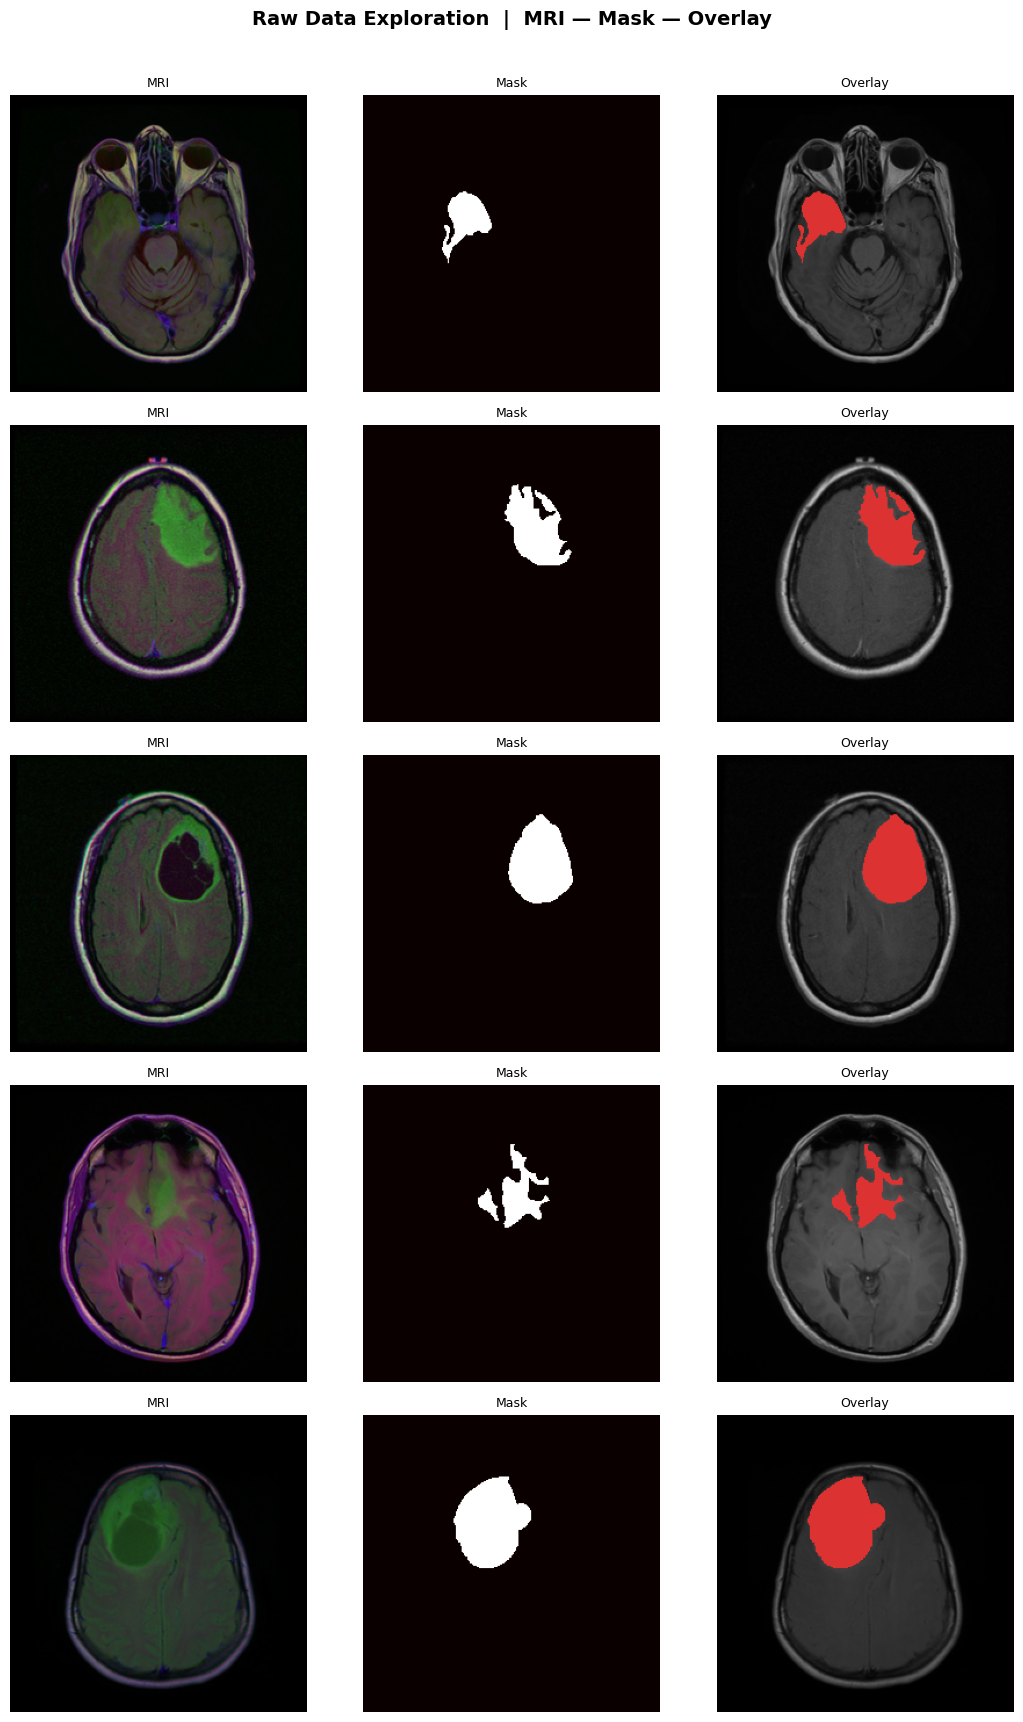

In [7]:
# ── Cell 5: Visualise raw samples ─────────────────────────────────────────────
# Show 5 slices WITH tumour + overlay
positive_pairs = [(i,m) for i,m in all_pairs if np.array(Image.open(m)).max()>0]
samples = random.sample(positive_pairs, 5)

fig, axes = plt.subplots(5, 3, figsize=(11, 17))
fig.suptitle('Raw Data Exploration  |  MRI — Mask — Overlay', fontsize=14, fontweight='bold', y=1.01)

for row, (ip, mp) in enumerate(samples):
    img  = np.array(Image.open(ip).convert('RGB'))
    mask = np.array(Image.open(mp).convert('L'))

    axes[row,0].imshow(img);                    axes[row,0].set_title('MRI', fontsize=9)
    axes[row,1].imshow(mask, cmap='hot');       axes[row,1].set_title('Mask', fontsize=9)

    # Overlay: blend mask in red over greyscale MRI
    grey = np.stack([img.mean(-1)]*3, axis=-1).astype(np.uint8)
    overlay = grey.copy()
    overlay[mask>127] = [220, 50, 50]
    axes[row,2].imshow(overlay);                axes[row,2].set_title('Overlay', fontsize=9)

    for ax in axes[row]: ax.axis('off')

plt.tight_layout(); plt.show()

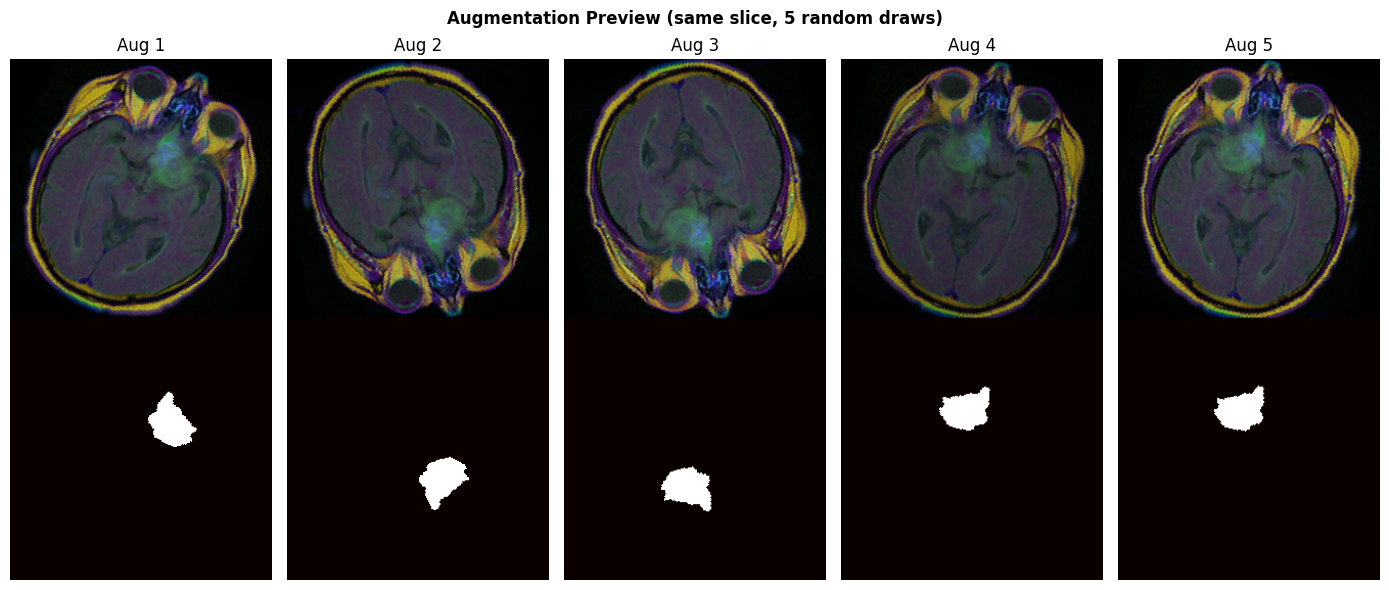

In [8]:
# ── Cell 6: Dataset class + augmentation preview ──────────────────────────────
class BrainMRIDataset(Dataset):
    def __init__(self, pairs, img_size=256, augment=False):
        self.pairs   = pairs
        self.size    = img_size
        self.augment = augment

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        ip, mp = self.pairs[idx]
        img  = Image.open(ip).convert('RGB').resize((self.size,self.size), Image.BILINEAR)
        mask = Image.open(mp).convert('L').resize((self.size,self.size), Image.NEAREST)

        if self.augment:
            if random.random()>0.5: img,mask = TF.hflip(img), TF.hflip(mask)
            if random.random()>0.5: img,mask = TF.vflip(img), TF.vflip(mask)
            angle = random.uniform(-30,30)
            img,mask = TF.rotate(img,angle), TF.rotate(mask,angle)
            if random.random()>0.5:
                img = TF.adjust_brightness(img, random.uniform(0.8,1.2))
                img = TF.adjust_contrast(img,   random.uniform(0.8,1.2))

        img  = TF.to_tensor(img)                                    # [3,H,W]
        mask = torch.from_numpy(np.array(mask)).float()
        mask = (mask>127).float().unsqueeze(0)                      # [1,H,W]
        return img, mask

# Preview augmentations on one positive sample
aug_ds = BrainMRIDataset(positive_pairs[:1], augment=True)
fig, axes = plt.subplots(2, 5, figsize=(14,6))
fig.suptitle('Augmentation Preview (same slice, 5 random draws)', fontweight='bold')
for col in range(5):
    im, mk = aug_ds[0]
    axes[0,col].imshow(im.permute(1,2,0).numpy())
    axes[0,col].set_title(f'Aug {col+1}'); axes[0,col].axis('off')
    axes[1,col].imshow(mk.squeeze().numpy(), cmap='hot')
    axes[1,col].axis('off')
axes[0,0].set_ylabel('Image', fontweight='bold')
axes[1,0].set_ylabel('Mask',  fontweight='bold')
plt.tight_layout(); plt.show()

In [9]:
# ── Cell 7: Train / Val / Test split + DataLoaders ────────────────────────────
train_pairs, temp  = train_test_split(all_pairs, test_size=CFG.val_split+CFG.test_split, random_state=CFG.seed)
val_pairs,  test_pairs = train_test_split(temp,
    test_size=CFG.test_split/(CFG.val_split+CFG.test_split), random_state=CFG.seed)

print(f'Train : {len(train_pairs)} | Val : {len(val_pairs)} | Test : {len(test_pairs)}')

train_ds = BrainMRIDataset(train_pairs, CFG.img_size, augment=True)
val_ds   = BrainMRIDataset(val_pairs,   CFG.img_size, augment=False)
test_ds  = BrainMRIDataset(test_pairs,  CFG.img_size, augment=False)

nw = 2
train_loader = DataLoader(train_ds, CFG.batch_size, shuffle=True,  num_workers=nw, pin_memory=True)
val_loader   = DataLoader(val_ds,   CFG.batch_size, shuffle=False, num_workers=nw, pin_memory=True)
test_loader  = DataLoader(test_ds,  CFG.batch_size, shuffle=False, num_workers=nw, pin_memory=True)

imgs, masks = next(iter(train_loader))
print(f'Batch — images: {tuple(imgs.shape)}  masks: {tuple(masks.shape)}')

Train : 2946 | Val : 589 | Test : 394
Batch — images: (16, 3, 256, 256)  masks: (16, 1, 256, 256)


In [10]:
# ── Cell 8: Attention U-Net architecture ─────────────────────────────────────
#
# Encoder  : ResNet-34 pretrained on ImageNet-1K (torchvision)
#   layer0/pool → 64ch   H/4
#   layer1      → 64ch   H/4
#   layer2      → 128ch  H/8
#   layer3      → 256ch  H/16
#   layer4      → 512ch  H/32
# Bottleneck: Conv block at H/32
# Decoder  : 4× UpConv + Attention Gate + skip concat + DoubleConv
# Deep supervision: auxiliary heads at each decoder stage (training only)
#
# Attention Gate (Oktay et al., 2018):
#   g   = gating signal (from deeper decoder level)
#   x   = skip connection (from encoder)
#   α   = sigmoid( W_g(g) + W_x(x) + b ) → spatial attention map ∈[0,1]
#   out = α * x   (attended skip)
#

# ── Attention Gate ────────────────────────────────────────────────────────────
class AttentionGate(nn.Module):
    """
    Additive attention gate.
    g  : gating signal  (B, g_ch, H, W)   — from the decoder (deeper, smaller)
    x  : skip feature   (B, x_ch, H', W') — from the encoder (shallower, larger)
    F_int: intermediate channel dim for the attention computation.
    """
    def __init__(self, g_ch, x_ch, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, F_int, kernel_size=1, bias=True),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, F_int, kernel_size=1, stride=1, bias=True),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # Upsample g to match x spatial size if needed
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=x.shape[2:], mode='bilinear', align_corners=False)
        g1  = self.W_g(g)
        x1  = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)          # (B, 1, H, W) attention map
        return x * psi               # attended skip


# ── Double Conv block ─────────────────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


# ── Decoder block with Attention Gate ────────────────────────────────────────
class AttDecoderBlock(nn.Module):
    """
    1. Upsample (ConvTranspose2d) the deeper feature map.
    2. Compute attention-gated skip via AttentionGate.
    3. Concatenate upsampled + attended-skip → DoubleConv.
    """
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up  = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.att = AttentionGate(g_ch=in_ch // 2, x_ch=skip_ch, F_int=skip_ch // 2)
        self.conv = DoubleConv(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x, skip):
        x    = self.up(x)                        # upsample
        skip = self.att(g=x, x=skip)             # attention-weighted skip
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


# ── Attention U-Net ───────────────────────────────────────────────────────────
class AttentionUNet(nn.Module):
    """
    U-Net with a pretrained ResNet-34 encoder and attention gates on skip connections.

    Input : (B, 3, H, W)  — RGB
    Output (eval) : (B, 1, H, W)  — raw logits
    Output (train): [(B,1,H,W), (B,1,H/2,W/2), (B,1,H/4,W/4), (B,1,H/8,W/8)]
                     main + 3 deep-supervision aux heads
    """
    def __init__(self, n_classes=1, pretrained=True):
        super().__init__()
        self.n_classes = n_classes

        # ── ResNet-34 encoder (torchvision) ──────────────────────────────────
        backbone = models.resnet34(weights='IMAGENET1K_V1' if pretrained else None)

        # Stem: conv1 + bn + relu  →  64ch, H/2
        self.enc0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)
        # Pool                     →  64ch, H/4
        self.pool  = backbone.maxpool
        # ResNet stages
        self.enc1  = backbone.layer1   # 64ch,  H/4
        self.enc2  = backbone.layer2   # 128ch, H/8
        self.enc3  = backbone.layer3   # 256ch, H/16
        self.enc4  = backbone.layer4   # 512ch, H/32

        # ── Bottleneck ────────────────────────────────────────────────────────
        self.bottleneck = DoubleConv(512, 1024)

        # ── Decoder with Attention Gates ──────────────────────────────────────
        # AttDecoderBlock(in_ch_from_prev, skip_ch, out_ch)
        self.dec4 = AttDecoderBlock(1024, 256, 512)   # H/16
        self.dec3 = AttDecoderBlock(512,  128, 256)   # H/8
        self.dec2 = AttDecoderBlock(256,   64,  128)  # H/4
        self.dec1 = AttDecoderBlock(128,   64,   64)  # H/2  (skip = enc0 stem)

        # Final upsample H/2 → H
        self.dec0 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            DoubleConv(32, 32),
        )

        # ── Segmentation head ─────────────────────────────────────────────────
        self.final = nn.Conv2d(32, n_classes, kernel_size=1)

        # ── Deep supervision auxiliary heads ──────────────────────────────────
        self.ds4 = nn.Conv2d(512, n_classes, 1)  # after dec4 → H/16
        self.ds3 = nn.Conv2d(256, n_classes, 1)  # after dec3 → H/8
        self.ds2 = nn.Conv2d(128, n_classes, 1)  # after dec2 → H/4

    def forward(self, x):
        H, W = x.shape[2:]

        # ── Encoder ───────────────────────────────────────────────────────────
        s0  = self.enc0(x)          # 64ch,  H/2
        p   = self.pool(s0)         # 64ch,  H/4
        s1  = self.enc1(p)          # 64ch,  H/4
        s2  = self.enc2(s1)         # 128ch, H/8
        s3  = self.enc3(s2)         # 256ch, H/16
        s4  = self.enc4(s3)         # 512ch, H/32

        # ── Bottleneck ────────────────────────────────────────────────────────
        b   = self.bottleneck(s4)   # 1024ch, H/32

        # ── Decoder ───────────────────────────────────────────────────────────
        d4  = self.dec4(b,  s3)     # 512ch,  H/16
        d3  = self.dec3(d4, s2)     # 256ch,  H/8
        d2  = self.dec2(d3, s1)     # 128ch,  H/4
        d1  = self.dec1(d2, s0)     # 64ch,   H/2
        d0  = self.dec0(d1)         # 32ch,   H

        main_out = self.final(d0)   # 1ch,    H

        if self.training:
            aux4 = F.interpolate(self.ds4(d4), size=(H, W), mode='bilinear', align_corners=False)
            aux3 = F.interpolate(self.ds3(d3), size=(H, W), mode='bilinear', align_corners=False)
            aux2 = F.interpolate(self.ds2(d2), size=(H, W), mode='bilinear', align_corners=False)
            return [main_out, aux2, aux3, aux4]   # main + 3 aux (shallow → deep)
        return main_out


# ── Build model ───────────────────────────────────────────────────────────────
model = AttentionUNet(n_classes=1, pretrained=True)

if torch.cuda.device_count() > 1:
    print(f'Wrapping model with DataParallel on {torch.cuda.device_count()} GPUs')
    model = nn.DataParallel(model)

model = model.to(CFG.device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Attention U-Net parameters: {total_params/1e6:.2f}M')

# Quick shape check
with torch.no_grad():
    model.eval()
    dummy = torch.zeros(1, 3, CFG.img_size, CFG.img_size).to(CFG.device)
    out   = model(dummy)
    print(f'Input → Output (eval): {tuple(dummy.shape)} → {tuple(out.shape)}')
    model.train()
    outs  = model(dummy)
    print(f'Output shapes (train/DS): {[tuple(o.shape) for o in outs]}')
    model.eval()


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 166MB/s] 


Wrapping model with DataParallel on 2 GPUs
Attention U-Net parameters: 46.25M
Input → Output (eval): (1, 3, 256, 256) → (1, 1, 256, 256)
Output shapes (train/DS): [(1, 1, 256, 256), (1, 1, 256, 256), (1, 1, 256, 256), (1, 1, 256, 256)]


In [11]:
# ── Cell 9: Loss, metrics & optimizer ────────────────────────────────────────

class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce    = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, targets):
        bce   = self.bce(logits, targets)
        prob  = torch.sigmoid(logits)
        inter = (prob * targets).sum(dim=(2, 3))
        dice  = 1 - (2*inter + self.smooth) / (
            prob.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth)
        return bce + dice.mean()


class DeepSupervisionLoss(nn.Module):
    """Weighted sum of DiceBCE at each DS scale."""
    def __init__(self, base_loss, weights):
        super().__init__()
        self.base   = base_loss
        self.weights = weights   # [w_main, w_aux1, w_aux2, w_aux3]

    def forward(self, preds, targets):
        """preds: list of logit tensors (all at same H×W after model upsamples)."""
        total = 0.
        for w, p in zip(self.weights, preds):
            total = total + w * self.base(p, targets)
        return total


def dice_score(logits, targets, thr=0.5, smooth=1e-6):
    p = (torch.sigmoid(logits) > thr).float()
    i = (p * targets).sum(dim=(2,3))
    return ((2*i+smooth)/(p.sum(dim=(2,3))+targets.sum(dim=(2,3))+smooth)).mean().item()

def iou_score(logits, targets, thr=0.5, smooth=1e-6):
    p = (torch.sigmoid(logits) > thr).float()
    i = (p * targets).sum(dim=(2,3))
    u = (p + targets - p*targets).sum(dim=(2,3))
    return ((i+smooth)/(u+smooth)).mean().item()


base_criterion = DiceBCELoss()
criterion      = DeepSupervisionLoss(base_criterion, CFG.ds_weights)

# ── Differential LR: ResNet encoder (pretrained) gets 10× smaller lr ─────────
base_model = model.module if isinstance(model, nn.DataParallel) else model

encoder_modules = [base_model.enc0, base_model.pool,
                   base_model.enc1, base_model.enc2,
                   base_model.enc3, base_model.enc4]
encoder_params  = [p for m in encoder_modules for p in m.parameters()]
encoder_ids     = {id(p) for p in encoder_params}
decoder_params  = [p for p in model.parameters() if id(p) not in encoder_ids]

optimizer = optim.Adam([
    {'params': encoder_params, 'lr': CFG.lr / 10},
    {'params': decoder_params, 'lr': CFG.lr},
], lr=CFG.lr)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=5, factor=0.5
)

print('Loss, metrics, optimizer ready ✓')


Loss, metrics, optimizer ready ✓


In [12]:
# ── Cell 10: Checkpoint helpers ───────────────────────────────

def save_checkpoint(epoch, model, optimizer, scheduler, history, best_dice, path):
    """Save full training state — resume from here later."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        'epoch':      epoch,
        'model':      model.state_dict(),
        'optimizer':  optimizer.state_dict(),
        'scheduler':  scheduler.state_dict(),
        'history':    history,
        'best_dice':  best_dice,
    }, path)
    print(f'  [ckpt] Checkpoint saved → {path}')


def load_checkpoint(path, model, optimizer, scheduler):
    """
    Load a full checkpoint.
    Returns (start_epoch, history, best_dice) so training continues
    from exactly where it stopped.
    """
    ckpt = torch.load(path, map_location=CFG.device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    print(f'  [ckpt] Resumed from epoch {ckpt["epoch"]} '
          f'(best val dice so far: {ckpt["best_dice"]:.4f})')
    return ckpt['epoch'], ckpt['history'], ckpt['best_dice']




In [13]:
# ── Try to resume from checkpoint ─────────────────────────────────────────
history    = {'tl':[],'vl':[],'td':[],'vd':[],'ti':[],'vi':[]}
best_dice  = 0.0
start_epoch = 1

if os.path.exists(CFG.checkpoint_path):
    print('Found existing checkpoint — resuming training...')
    start_epoch, history, best_dice = load_checkpoint(
        CFG.checkpoint_path, model, optimizer, scheduler
    )
    start_epoch += 1  # continue from next epoch
else:
    print('No checkpoint found — starting fresh.')




No checkpoint found — starting fresh.


In [14]:
# ── Epoch functions ────────────────────────────────────────────────────────
def train_epoch(model, loader, opt, crit, dev):
    model.train()
    ls, ds, iou_acc = 0., 0., 0.
    for imgs, masks in loader:
        imgs, masks = imgs.to(dev), masks.to(dev)
        opt.zero_grad()

        preds = model(imgs)          # list of 4 tensors (deep supervision)
        loss  = crit(preds, masks)   # DeepSupervisionLoss
        loss.backward()
        opt.step()

        main_logits = preds[0].detach()   # main head for metrics
        ls      += loss.item()
        ds      += dice_score(main_logits, masks)
        iou_acc += iou_score(main_logits, masks)

    n = len(loader)
    return ls/n, ds/n, iou_acc/n


@torch.no_grad()
def val_epoch(model, loader, crit, dev):
    model.eval()
    ls, ds, iou_acc = 0., 0., 0.
    for imgs, masks in loader:
        imgs, masks = imgs.to(dev), masks.to(dev)
        logits = model(imgs)          # single tensor in eval mode
        ls      += base_criterion(logits, masks).item()
        ds      += dice_score(logits, masks)
        iou_acc += iou_score(logits, masks)
    n = len(loader)
    return ls/n, ds/n, iou_acc/n

print('Epoch functions ready ✓')


Epoch functions ready ✓


In [15]:
# ── Main loop ─────────────────────────────────────────────────────────────
remaining = CFG.num_epochs - start_epoch + 1
if remaining <= 0:
    print(f'Already trained {CFG.num_epochs} epochs. Increase CFG.num_epochs to continue.')
else:
    print(f'Training epochs {start_epoch}–{CFG.num_epochs} on {CFG.device} ...\n')
    print(f'{"Epoch":>6} {"T-Loss":>8} {"V-Loss":>8} {"T-Dice":>8} '
          f'{"V-Dice":>8} {"T-IoU":>7} {"V-IoU":>7}')
    print('-'*58)

    for epoch in range(start_epoch, CFG.num_epochs + 1):
        tl,td,ti = train_epoch(model, train_loader, optimizer, criterion, CFG.device)
        vl,vd,vi = val_epoch(model, val_loader, criterion, CFG.device)
        scheduler.step(vd)

        history['tl'].append(tl); history['vl'].append(vl)
        history['td'].append(td); history['vd'].append(vd)
        history['ti'].append(ti); history['vi'].append(vi)

        star = ''
        if vd > best_dice:
            best_dice = vd
            # Save only weights for the best model
            os.makedirs(os.path.dirname(CFG.best_model_path), exist_ok=True)
            torch.save(model.state_dict(), CFG.best_model_path)
            star = ' ★'

        # Save full checkpoint every epoch (overwrites previous)
        save_checkpoint(
            epoch, model, optimizer, scheduler,
            history, best_dice, CFG.checkpoint_path
        )

        print(f'{epoch:>6} {tl:>8.4f} {vl:>8.4f} {td:>8.4f} '
              f'{vd:>8.4f} {ti:>7.4f} {vi:>7.4f}{star}')

    print(f'\n Training complete — Best Val Dice: {best_dice:.4f}')


Training epochs 1–40 on cuda ...

 Epoch   T-Loss   V-Loss   T-Dice   V-Dice   T-IoU   V-IoU
----------------------------------------------------------
  [ckpt] Checkpoint saved → ./attunet_checkpoint.pth
     1   1.2288   1.2385   0.6233   0.8048  0.5887  0.7651 ★
  [ckpt] Checkpoint saved → ./attunet_checkpoint.pth
     2   1.0777   1.2114   0.7492   0.5143  0.7086  0.4688
  [ckpt] Checkpoint saved → ./attunet_checkpoint.pth
     3   1.0075   1.1306   0.7684   0.8226  0.7284  0.7841 ★
  [ckpt] Checkpoint saved → ./attunet_checkpoint.pth
     4   0.9496   1.0292   0.7917   0.8173  0.7536  0.7769
  [ckpt] Checkpoint saved → ./attunet_checkpoint.pth
     5   0.9070   0.9984   0.7939   0.8307  0.7580  0.7948 ★
  [ckpt] Checkpoint saved → ./attunet_checkpoint.pth
     6   0.8718   0.9429   0.8256   0.7283  0.7906  0.6852
  [ckpt] Checkpoint saved → ./attunet_checkpoint.pth
     7   0.8415   0.9313   0.8124   0.5755  0.7782  0.5400
  [ckpt] Checkpoint saved → ./attunet_checkpoint.pth
     

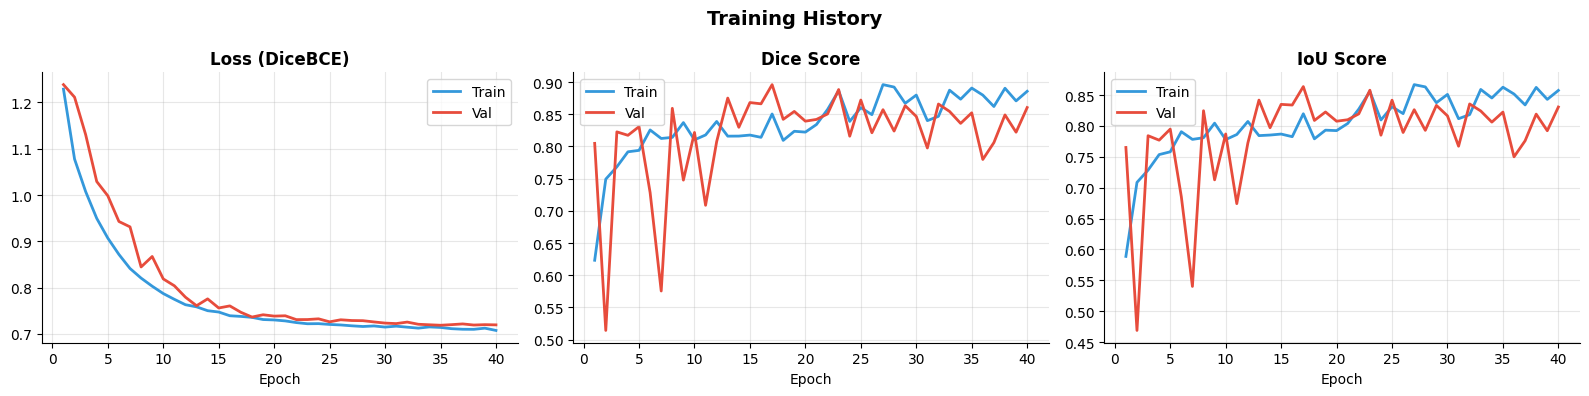

Saved: ./training_curves.png


In [16]:
# ── Cell 11: Learning curves ──────────────────────────────────────────────────
actual_num_epochs = len(history['tl'])
epochs = range(1, actual_num_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

titles   = ['Loss (DiceBCE)', 'Dice Score', 'IoU Score']
t_series = [history['tl'], history['td'], history['ti']]
v_series = [history['vl'], history['vd'], history['vi']]

for ax, title, tr, vl in zip(axes, titles, t_series, v_series):
    ax.plot(epochs, tr, label='Train', color='#3498db', linewidth=2)
    ax.plot(epochs, vl, label='Val',   color='#e74c3c', linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('./training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./training_curves.png')

In [17]:
# ── Cell 12: Test set evaluation ──────────────────────────────────────────────
model.load_state_dict(torch.load(CFG.best_model_path, map_location=CFG.device))
ts_loss, ts_dice, ts_iou = val_epoch(model, test_loader, criterion, CFG.device)

print('=' * 40)
print(f'  TEST RESULTS (best checkpoint)')
print('=' * 40)
print(f'  Loss   : {ts_loss:.4f}')
print(f'  Dice   : {ts_dice:.4f}')
print(f'  IoU    : {ts_iou:.4f}')
print('=' * 40)

  TEST RESULTS (best checkpoint)
  Loss   : 0.7589
  Dice   : 0.9023
  IoU    : 0.8736


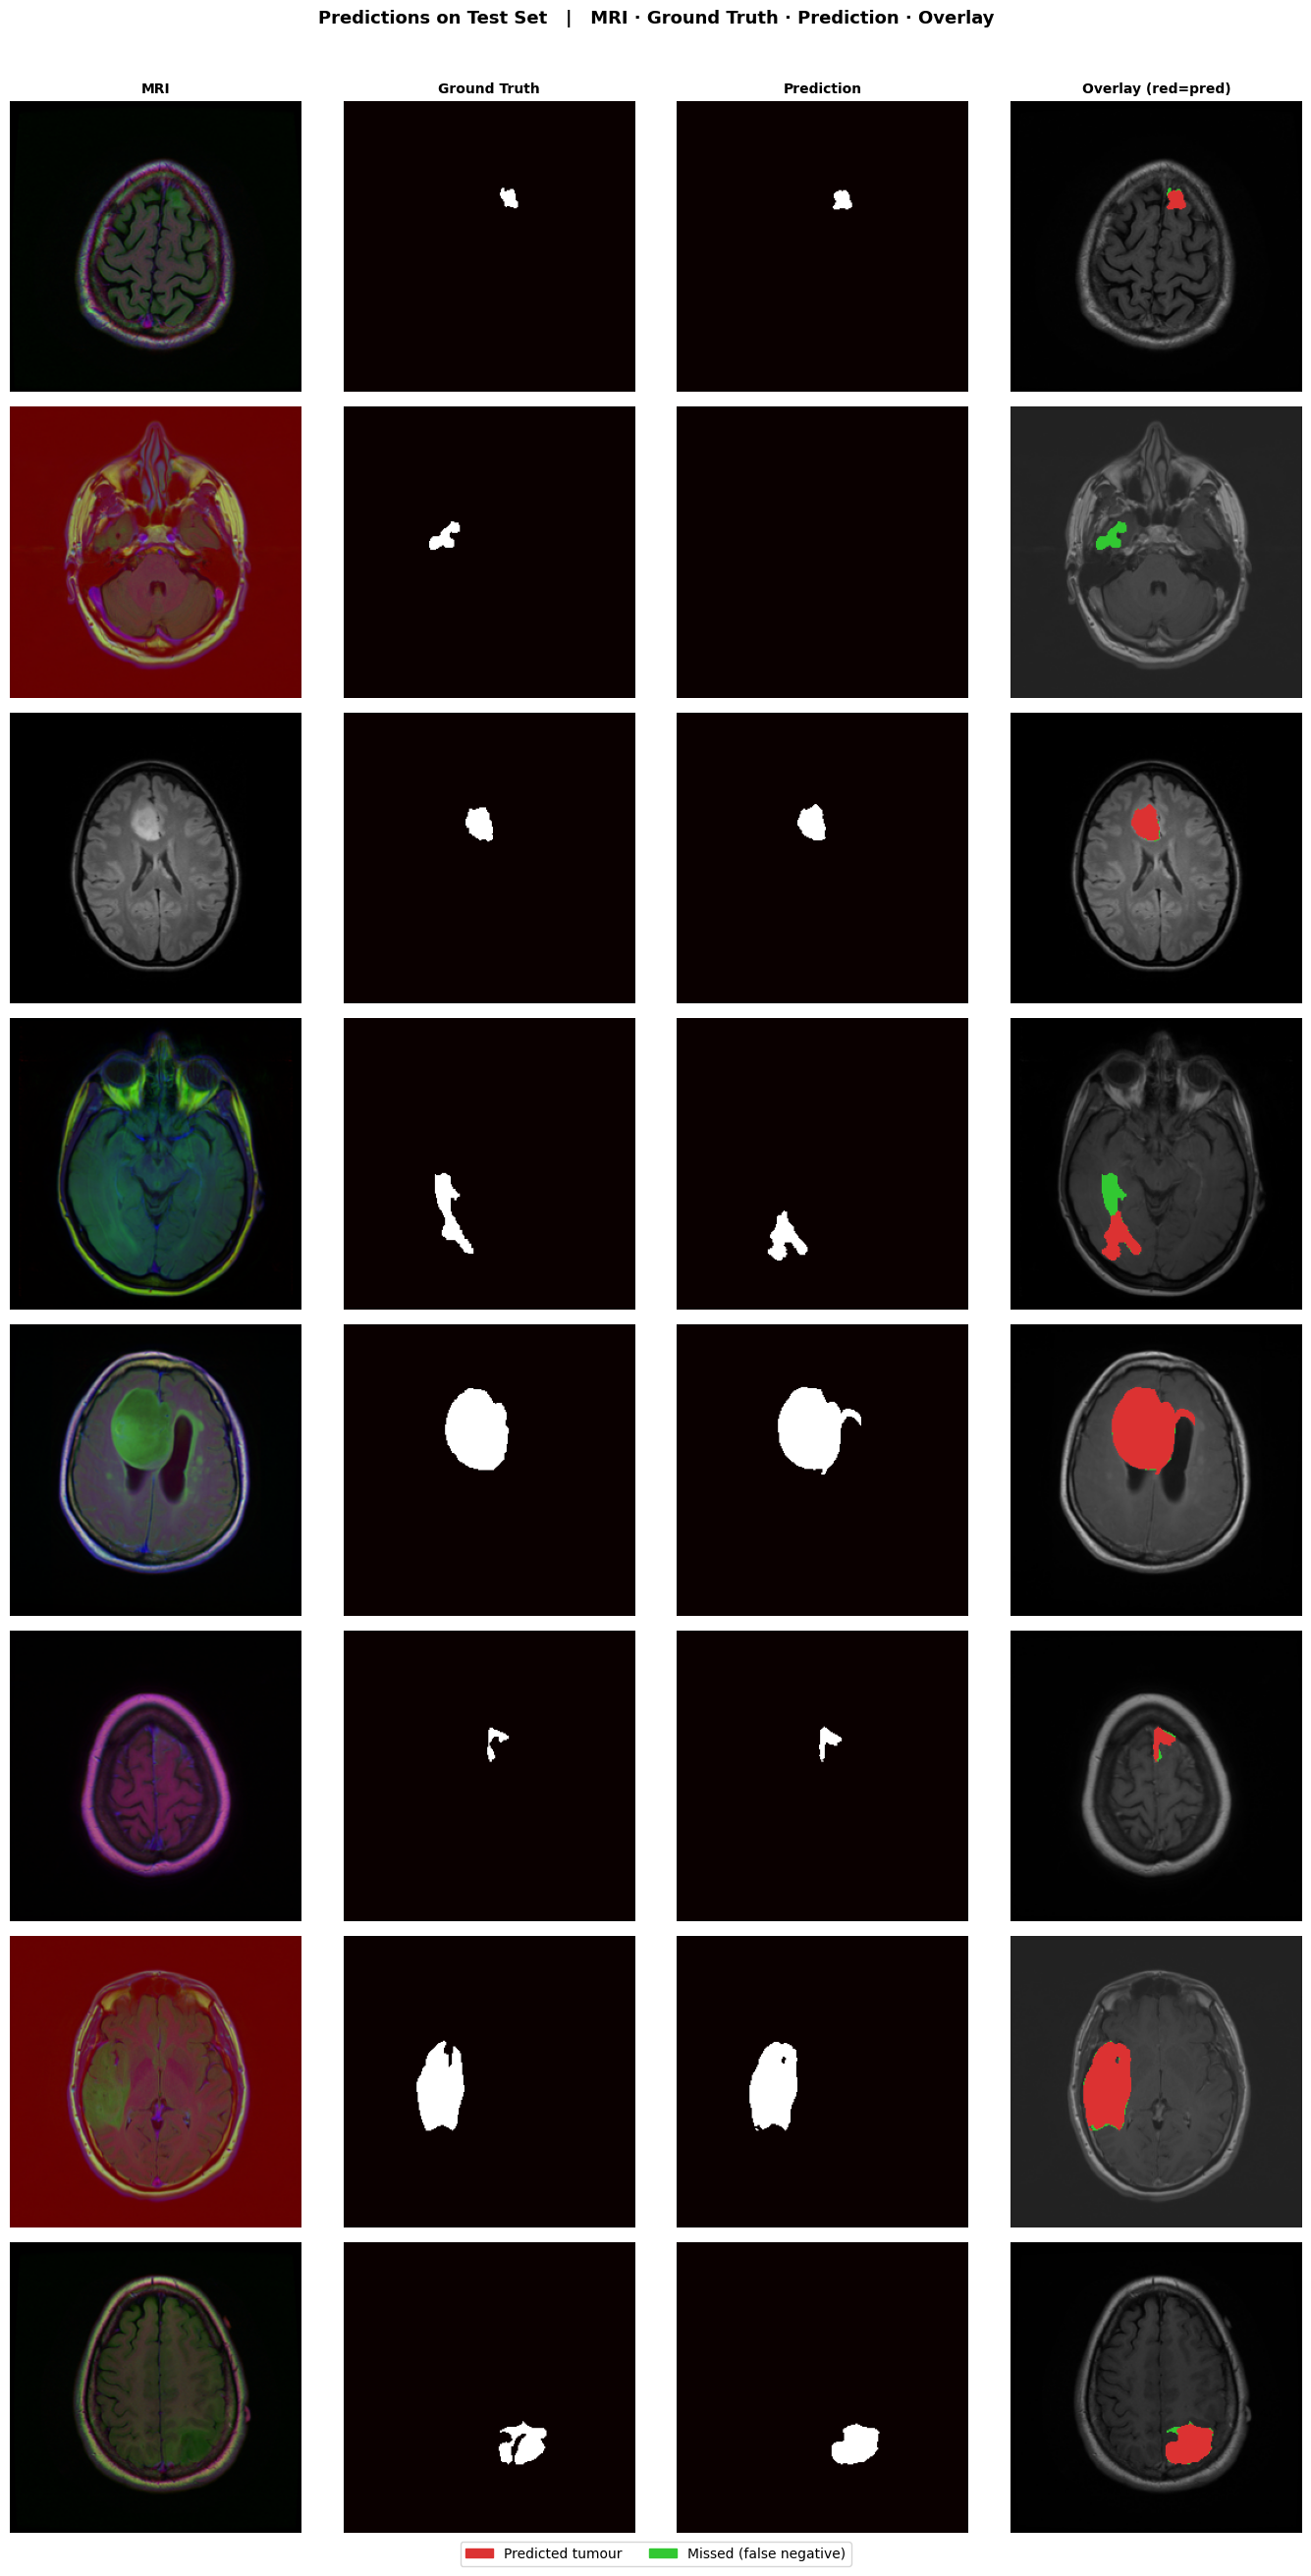

Saved: ./predictions.png


In [18]:
# ── Cell 13: Qualitative predictions ─────────────────────────────────────────
@torch.no_grad()
def predict_single(model, img_path, device=CFG.device, size=CFG.img_size, thr=0.35):
    model.eval()
    img   = Image.open(img_path).convert('RGB')
    orig  = np.array(img)
    inp   = TF.to_tensor(img.resize((size,size), Image.BILINEAR)).unsqueeze(0).to(device)
    prob  = torch.sigmoid(model(inp)).squeeze().cpu().numpy()
    mask  = (prob > thr).astype(np.uint8)
    mask  = np.array(Image.fromarray(mask*255).resize(orig.shape[1::-1], Image.NEAREST))
    return orig, mask, prob


# Sample from positive test slices only — more interesting to visualise
pos_test = [(i,m) for i,m in test_pairs if np.array(Image.open(m)).max()>0]
n_show   = min(8, len(pos_test))
samples  = random.sample(pos_test, n_show)

fig, axes = plt.subplots(n_show, 4, figsize=(14, n_show*3.2))
fig.suptitle('Predictions on Test Set   |   MRI · Ground Truth · Prediction · Overlay',
             fontsize=13, fontweight='bold', y=1.01)

col_titles = ['MRI', 'Ground Truth', 'Prediction', 'Overlay (red=pred)']
for col, t in enumerate(col_titles):
    axes[0,col].set_title(t, fontweight='bold', fontsize=10)

for row, (ip, mp) in enumerate(samples):
    orig, pred, prob = predict_single(model, ip)
    gt = np.array(Image.open(mp).convert('L'))

    # Overlay: grey base + red predicted pixels
    grey    = np.stack([orig.mean(-1)]*3, axis=-1).astype(np.uint8)
    overlay = grey.copy()
    overlay[pred>127] = [220, 50, 50]
    # Green for ground truth in overlay too
    overlay[(gt>127) & (pred<=127)] = [50, 200, 50]   # fn = green

    axes[row,0].imshow(orig)
    axes[row,1].imshow(gt,      cmap='hot', vmin=0, vmax=255)
    axes[row,2].imshow(pred,    cmap='hot', vmin=0, vmax=255)
    axes[row,3].imshow(overlay)
    for ax in axes[row]: ax.axis('off')

# Legend
red_patch   = mpatches.Patch(color='#dc3232', label='Predicted tumour')
green_patch = mpatches.Patch(color='#32c832', label='Missed (false negative)')
fig.legend(handles=[red_patch, green_patch], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig('./predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./predictions.png')

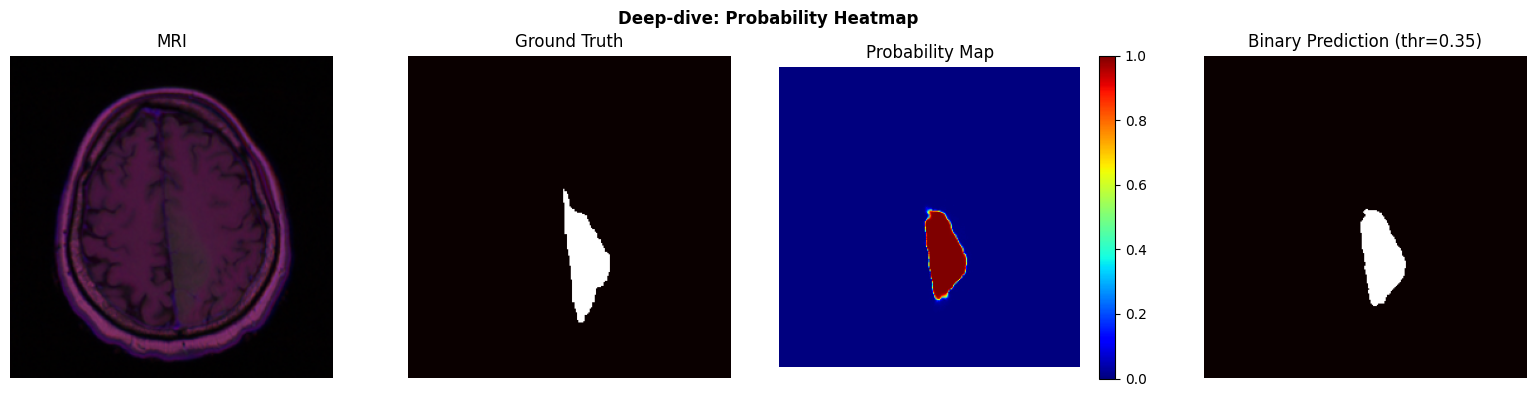

Saved: ./ProbaHetmap.png


In [19]:
# ── Cell 14: Probability heatmap ──────────────────────────────────────────────
sample_ip, sample_mp = random.choice(pos_test)
orig, pred, prob = predict_single(model, sample_ip)
gt = np.array(Image.open(sample_mp).convert('L'))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Deep-dive: Probability Heatmap', fontweight='bold')

axes[0].imshow(orig);                                 axes[0].set_title('MRI')
axes[1].imshow(gt,   cmap='hot', vmin=0,vmax=255);   axes[1].set_title('Ground Truth')
im = axes[2].imshow(prob, cmap='jet', vmin=0,vmax=1)
plt.colorbar(im, ax=axes[2]); axes[2].set_title('Probability Map')
axes[3].imshow(pred, cmap='hot', vmin=0,vmax=255);   axes[3].set_title('Binary Prediction (thr=0.35)')
for ax in axes: ax.axis('off')

plt.tight_layout(); 
plt.savefig('./ProbaHetmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./ProbaHetmap.png')

In [26]:
from IPython.display import FileLink
FileLink('attunet_checkpoint.pth')


/kaggle/working/attunet_checkpoint.pth